# L2-T3: Fraud Detection

## Objective
Build a machine learning pipeline to detect fraudulent financial transactions from a heavily imbalanced dataset.

## Dataset
Credit Card Fraud Detection Dataset

## Technologies
Python, Pandas, NumPy, Scikit-learn, Imbalanced-learn, Matplotlib, Seaborn

In [102]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from imblearn.over_sampling import SMOTE

print("All libraries imported successfully!")

All libraries imported successfully!


In [104]:
df = pd.read_csv("../dataset/creditcard.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()


Dataset loaded successfully!
Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [105]:
import os

print(os.path.exists("../dataset/creditcard.csv"))

True


In [106]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of rows: 284807
Number of columns: 31

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 no

In [107]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [108]:
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values by column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0


In [109]:
class_counts = df["Class"].value_counts()

print("Class Distribution:")
print(class_counts)

fraud_count = (df["Class"] == 1).sum()
non_fraud_count = (df["Class"] == 0).sum()

fraud_percentage = fraud_count / len(df) * 100
non_fraud_percentage = non_fraud_count / len(df) * 100

print("\nTotal transactions:", len(df))
print("Fraudulent transactions:", fraud_count)
print("Non-fraudulent transactions:", non_fraud_count)

print(f"\nFraud percentage: {fraud_percentage:.4f}%")
print(f"Non-fraud percentage: {non_fraud_percentage:.4f}%")

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Total transactions: 284807
Fraudulent transactions: 492
Non-fraudulent transactions: 284315

Fraud percentage: 0.1727%
Non-fraud percentage: 99.8273%


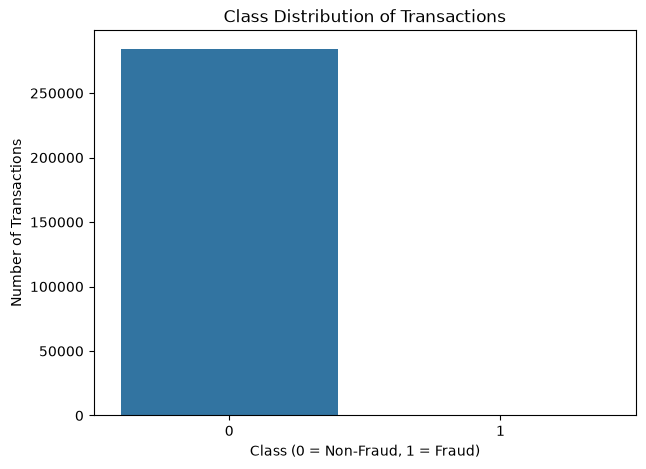

In [110]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Class Distribution of Transactions")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

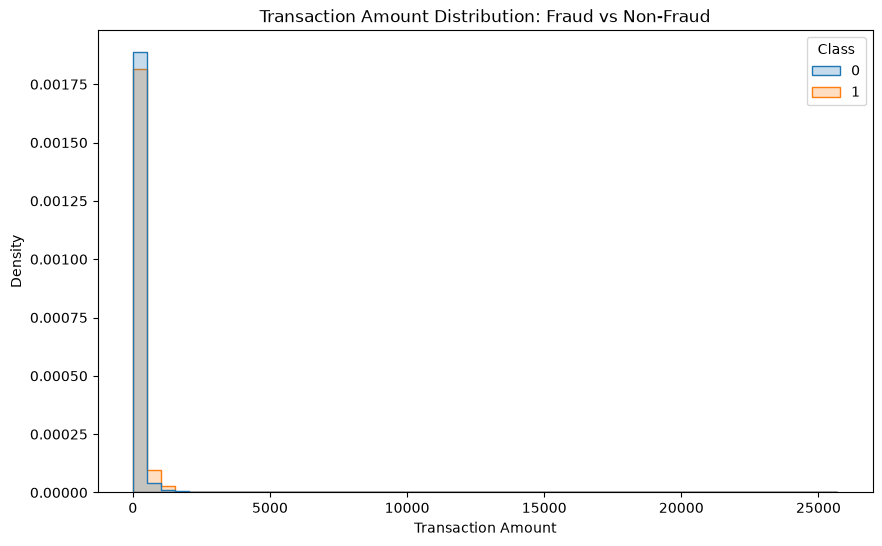

In [111]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.show()

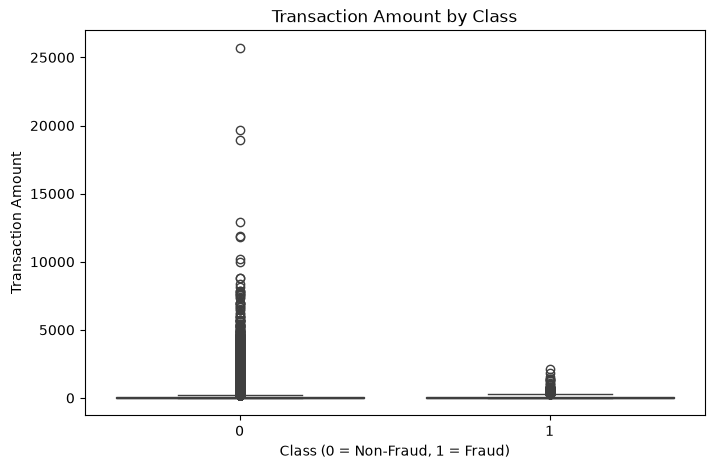

In [122]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [123]:
# Convert transaction time from seconds to hour of day

df["Hour"] = (df["Time"] / 3600) % 24
df["Hour"] = df["Hour"].astype(int)

df[["Time", "Hour", "Class"]].head()

,Time,Hour,Class
0,0.0,0,0
1,0.0,0,0
2,1.0,0,0
3,1.0,0,0
4,2.0,0,0


In [124]:
# Calculate fraud percentage for each hour

fraud_by_hour = df.groupby("Hour")["Class"].mean() * 100

print("Fraud percentage by hour:")
print(fraud_by_hour)

Fraud percentage by hour:
Hour
0     0.077973
1     0.236967
2     1.712740
3     0.486827
4     1.041195
5     0.367893
6     0.219459
7     0.317548
8     0.087583
9     0.101023
10    0.048199
11    0.314428
12    0.110246
13    0.110641
14    0.138805
15    0.157949
16    0.133714
17    0.179389
18    0.193673
19    0.121414
20    0.107424
21    0.090380
22    0.058286
23    0.191991
Name: Class, dtype: float64


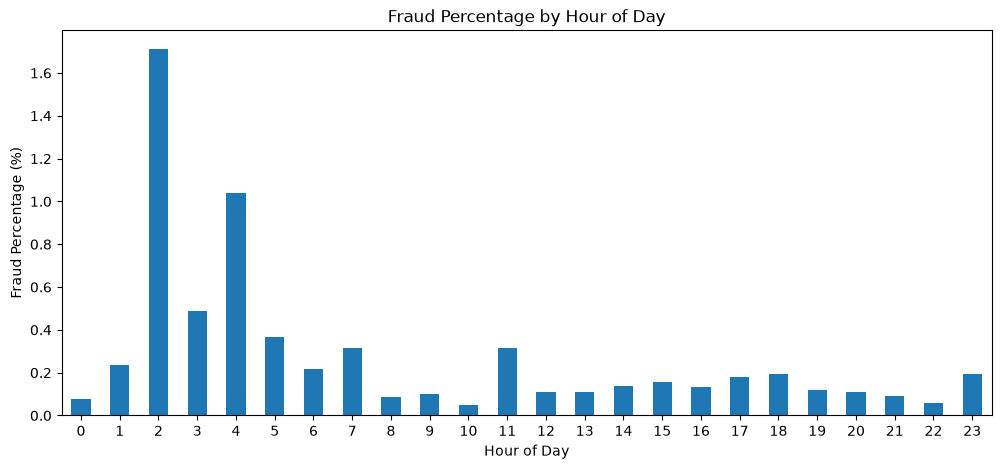

In [130]:
plt.figure(figsize=(12, 5))

fraud_by_hour.plot(kind="bar")

plt.title("Fraud Percentage by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Percentage (%)")

plt.xticks(rotation=0)

plt.show()

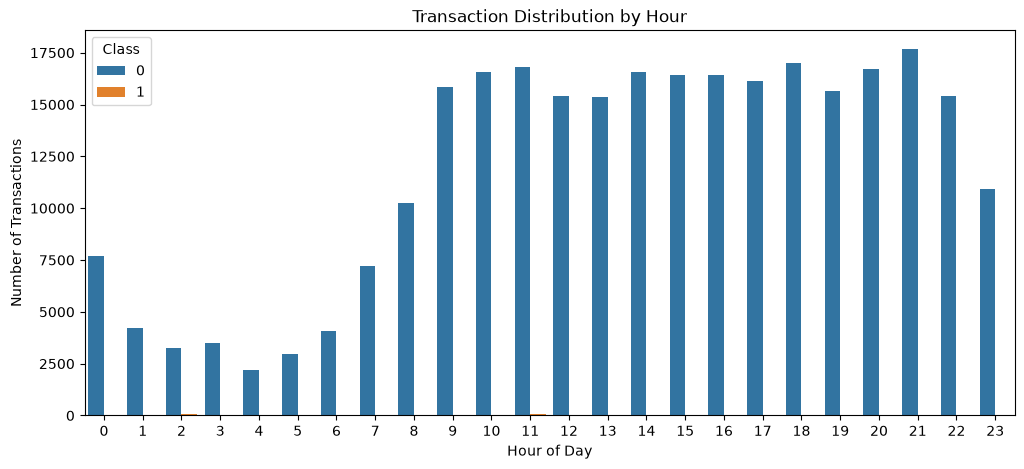

In [125]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="Hour",
    hue="Class"
)

plt.title("Transaction Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

### Why Accuracy Is Misleading for Imbalanced Fraud Detection

The dataset is highly imbalanced because fraudulent transactions represent only about 0.17% of all transactions. Standard accuracy can therefore be misleading. A model that predicts every transaction as non-fraudulent could achieve approximately 99.83% accuracy while detecting none of the actual fraudulent transactions. Therefore, fraud detection should focus on Precision, Recall, F1-Score, and ROC-AUC rather than accuracy alone.

In [126]:
# Define features and target

X = df.drop(columns=["Class", "Hour"])
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (284807, 30)
Target shape: (284807,)


In [127]:
# Stratified Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training set shape: (227845, 30)
Testing set shape: (56962, 30)

Training Class Distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing Class Distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [128]:
# Standardize features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled Training Shape: (227845, 30)
Scaled Testing Shape: (56962, 30)


In [129]:
# Apply SMOTE to the training data only

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


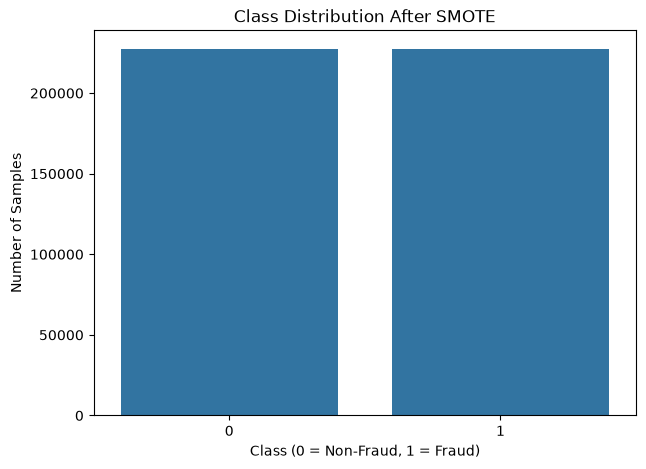

In [99]:
plt.figure(figsize=(7, 5))

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Samples")

plt.show()

In [100]:
# Train Logistic Regression model

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [101]:
# Make predictions using Logistic Regression

y_pred_log = log_model.predict(X_test_scaled)

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression predictions completed!")

Logistic Regression predictions completed!


In [112]:
# Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [113]:
# Make predictions using Random Forest

y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [114]:
# Evaluate Logistic Regression

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

print("LOGISTIC REGRESSION")
print("-----------------------------")
print(f"Accuracy  : {log_accuracy:.4f}")
print(f"Precision : {log_precision:.4f}")
print(f"Recall    : {log_recall:.4f}")
print(f"F1-Score  : {log_f1:.4f}")
print(f"ROC-AUC   : {log_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

LOGISTIC REGRESSION
-----------------------------
Accuracy  : 0.9741
Precision : 0.0578
Recall    : 0.9184
F1-Score  : 0.1088
ROC-AUC   : 0.9708

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [115]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("RANDOM FOREST")
print("-----------------------------")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
-----------------------------
Accuracy  : 0.9988
Precision : 0.6212
Recall    : 0.8367
F1-Score  : 0.7130
ROC-AUC   : 0.9729

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.62      0.84      0.71        98

    accuracy                           1.00     56962
   macro avg       0.81      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962



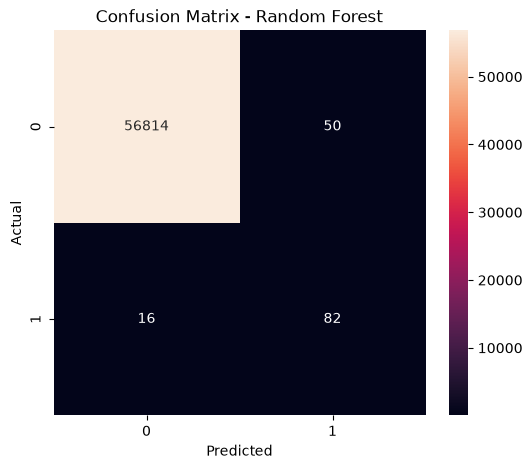

In [116]:
# Confusion Matrix - Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

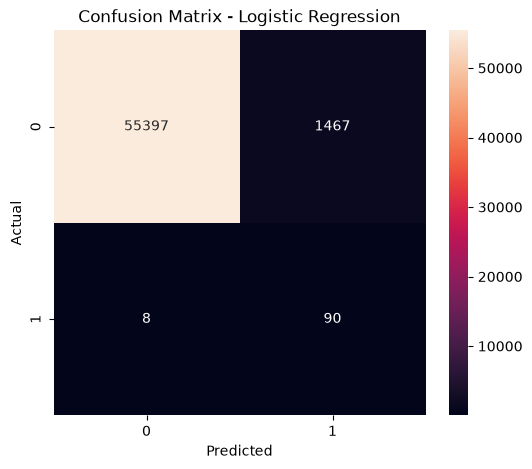

In [117]:
# Confusion Matrix - Logistic Regression

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [118]:
# Compare Logistic Regression and Random Forest

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        rf_accuracy
    ],
    "Precision": [
        log_precision,
        rf_precision
    ],
    "Recall": [
        log_recall,
        rf_recall
    ],
    "F1-Score": [
        log_f1,
        rf_f1
    ],
    "ROC-AUC": [
        log_auc,
        rf_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.974106,0.057803,0.918367,0.108761,0.970843
1,Random Forest,0.998841,0.621212,0.836735,0.713043,0.972943


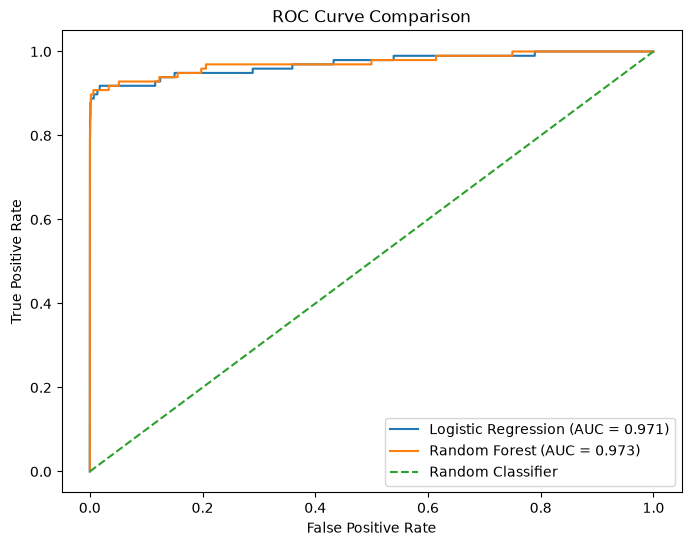

In [119]:
# ROC Curve Comparison

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {log_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [120]:
# Random Forest Feature Importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
V14    0.289198
V10    0.100619
V4     0.094927
V17    0.086248
V3     0.077684
V12    0.069758
V16    0.051961
V2     0.023085
V7     0.022042
V9     0.020534
V11    0.013663
V8     0.013509
V19    0.013392
V27    0.011329
V21    0.011044
dtype: float64


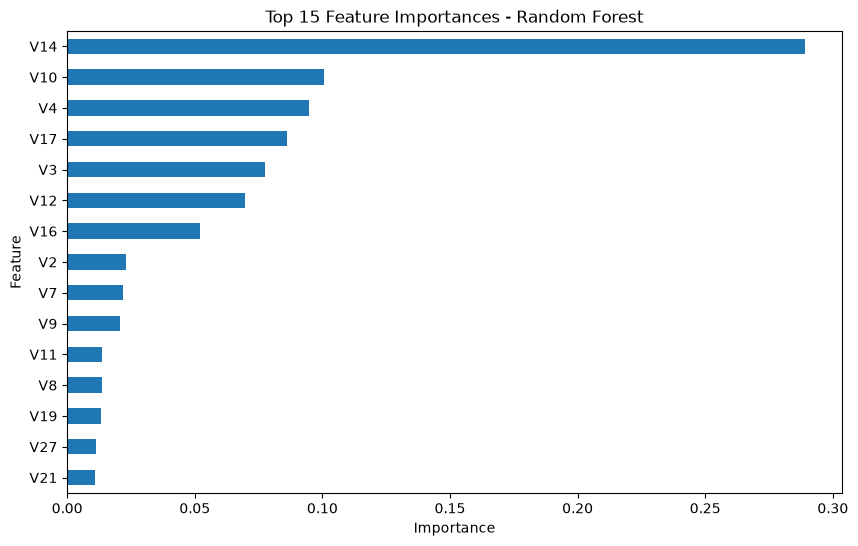

In [121]:
plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Which Metric Matters Most for Fraud Detection?

Recall is particularly important in fraud detection because it measures the proportion of actual fraudulent transactions that are correctly identified. A false negative means that a fraudulent transaction is classified as legitimate, which can result in financial loss.

However, Precision is also important because a large number of false positives can cause legitimate transactions to be flagged as fraudulent, creating inconvenience for customers.

In this project, Logistic Regression achieved a higher Recall of 91.84%, while Random Forest achieved a Recall of 83.67%. However, Logistic Regression had very low Precision of 5.78%, whereas Random Forest achieved much better Precision of 62.12%. Random Forest also achieved a much higher F1-Score of 71.30% compared with 10.88% for Logistic Regression.

Therefore, Recall is highly important when the main objective is to minimize missed fraud cases, but Precision must also be considered to control false alarms. For this project, Random Forest provides a better balance between Precision and Recall.

### Scalability: Handling 1 Million Transactions per Hour

A system processing 1 million transactions per hour would need to handle approximately 278 transactions per second. To support this workload, the fraud detection model could be deployed as a real-time prediction service with batch or streaming processing.

Transaction data could be received through a distributed streaming system, while the trained model could process transactions in parallel. Random Forest prediction can be parallelized, and the model-serving infrastructure can be scaled horizontally as transaction volume increases.

The system should also monitor prediction latency, throughput, false positives and false negatives. Suspicious transactions can be sent for further investigation, while prediction results can be stored for auditing and analysis. Periodic retraining would be useful because fraud patterns can change over time.